# Dataset overview

In [26]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [27]:
import pandas as pd

In [28]:
df = pd.read_csv('../data/raw/delay_short.csv')

In [29]:
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2009,5,AS,Alaska Airlines Inc.,DCA,"Washington, DC: Ronald Reagan Washington National",93.0,12.0,4.63,0.00,...,0.00,0.00,0.0,1.0,578.0,306.0,0.0,272.0,0.0,0.0
1,2004,12,AA,American Airlines Inc.,OAK,"Oakland, CA: Metropolitan Oakland International",153.0,52.0,18.16,3.84,...,1.85,13.61,2.0,0.0,2860.0,935.0,314.0,466.0,64.0,1081.0
2,2019,12,C5,"Commutair Aka Champlain Enterprises, Inc.",BTV,"Burlington, VT: Burlington International",60.0,17.0,7.83,0.27,...,0.00,4.98,2.0,0.0,1654.0,955.0,18.0,157.0,0.0,524.0
3,2019,6,OH,PSA Airlines Inc.,SRQ,"Sarasota/Bradenton, FL: Sarasota/Bradenton Int...",90.0,16.0,3.43,2.84,...,0.00,5.83,1.0,1.0,1604.0,696.0,234.0,142.0,0.0,532.0
4,2025,9,C5,CommuteAir LLC dba CommuteAir,ECP,"Panama City, FL: Northwest Florida Beaches Int...",46.0,4.0,1.24,0.00,...,0.00,1.57,0.0,1.0,154.0,37.0,0.0,29.0,0.0,88.0


In [30]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [31]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

In [32]:
df.columns

Index(['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name',
       'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct',
       'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted',
       'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay',
       'security_delay', 'late_aircraft_delay'],
      dtype='object')

In [33]:
# create date column
df["date"] = pd.to_datetime(
    df[["year", "month"]].assign(DAY=1)
)
df = df.set_index("date")

In [34]:
# quick check the time series data type
df = df.reset_index()
df.head()

,date,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2009-05-01,2009,5,AS,Alaska Airlines Inc.,DCA,"Washington, DC: Ronald Reagan Washington National",93.0,12.0,4.63,...,0.00,0.00,0.0,1.0,578.0,306.0,0.0,272.0,0.0,0.0
1,2004-12-01,2004,12,AA,American Airlines Inc.,OAK,"Oakland, CA: Metropolitan Oakland International",153.0,52.0,18.16,...,1.85,13.61,2.0,0.0,2860.0,935.0,314.0,466.0,64.0,1081.0
2,2019-12-01,2019,12,C5,"Commutair Aka Champlain Enterprises, Inc.",BTV,"Burlington, VT: Burlington International",60.0,17.0,7.83,...,0.00,4.98,2.0,0.0,1654.0,955.0,18.0,157.0,0.0,524.0
3,2019-06-01,2019,6,OH,PSA Airlines Inc.,SRQ,"Sarasota/Bradenton, FL: Sarasota/Bradenton Int...",90.0,16.0,3.43,...,0.00,5.83,1.0,1.0,1604.0,696.0,234.0,142.0,0.0,532.0
4,2025-09-01,2025,9,C5,CommuteAir LLC dba CommuteAir,ECP,"Panama City, FL: Northwest Florida Beaches Int...",46.0,4.0,1.24,...,0.00,1.57,0.0,1.0,154.0,37.0,0.0,29.0,0.0,88.0


In [35]:
# drop unnecessary columns
df = df.drop(columns=["Date", "level_0", "index"], errors="ignore")

In [36]:
df.head()

,date,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2009-05-01,2009,5,AS,Alaska Airlines Inc.,DCA,"Washington, DC: Ronald Reagan Washington National",93.0,12.0,4.63,...,0.00,0.00,0.0,1.0,578.0,306.0,0.0,272.0,0.0,0.0
1,2004-12-01,2004,12,AA,American Airlines Inc.,OAK,"Oakland, CA: Metropolitan Oakland International",153.0,52.0,18.16,...,1.85,13.61,2.0,0.0,2860.0,935.0,314.0,466.0,64.0,1081.0
2,2019-12-01,2019,12,C5,"Commutair Aka Champlain Enterprises, Inc.",BTV,"Burlington, VT: Burlington International",60.0,17.0,7.83,...,0.00,4.98,2.0,0.0,1654.0,955.0,18.0,157.0,0.0,524.0
3,2019-06-01,2019,6,OH,PSA Airlines Inc.,SRQ,"Sarasota/Bradenton, FL: Sarasota/Bradenton Int...",90.0,16.0,3.43,...,0.00,5.83,1.0,1.0,1604.0,696.0,234.0,142.0,0.0,532.0
4,2025-09-01,2025,9,C5,CommuteAir LLC dba CommuteAir,ECP,"Panama City, FL: Northwest Florida Beaches Int...",46.0,4.0,1.24,...,0.00,1.57,0.0,1.0,154.0,37.0,0.0,29.0,0.0,88.0


In [37]:
len(df) # count total rows

55000

In [38]:
# Count missing values in the DataFrame
missing_values = df.isnull().sum()
print(missing_values)

date                     0
year                     0
month                    0
carrier                  0
carrier_name             0
airport                  0
airport_name             0
arr_flights             81
arr_del15              122
carrier_ct              81
weather_ct              81
nas_ct                  81
security_ct             81
late_aircraft_ct        81
arr_cancelled           81
arr_diverted            81
arr_delay               81
carrier_delay           81
weather_delay           81
nas_delay               81
security_delay          81
late_aircraft_delay     81
dtype: int64


Die Abweichung total_num_rows vs count ist 664, und sie sind null values. 

In [39]:
df["year"].unique()

array([2009, 2004, 2019, 2025, 2022, 2006, 2013, 2018, 2011, 2023, 2015,
       2007, 2010, 2016, 2017, 2024, 2005, 2020, 2008, 2021, 2012, 2026,
       2003, 2014])

In [40]:
# check for completeness in each year
monthly_counts = df.groupby('year')['month'].nunique()

# Filter out years with fewer than 12 months
incomplete_years = monthly_counts[monthly_counts < 12]

if incomplete_years.empty:
    print("Every year has all 12 months.")
else:
    print(f"Incomplete years found ({len(incomplete_years)} total):")
    # Loop through each years to print readable output
    for year, num_months in incomplete_years.items():
        print(f"Year {year} has {num_months} months.")

Incomplete years found (2 total):
Year 2003 has 7 months.
Year 2026 has 3 months.


In [41]:
# Full set of expected months (1 through 12)
all_months = set(range(1, 13))

# Loop through the incomplete years to find the gaps
for year in incomplete_years.index:
    existing_months = set(df[df['year'] == year]['month'])
    missing_months = sorted(list(all_months - existing_months))
    print(f"Year {year} is missing months: {missing_months}")

Year 2003 is missing months: [1, 2, 3, 4, 5]
Year 2026 is missing months: [4, 5, 6, 7, 8, 9, 10, 11, 12]


# Overall trend of delay causes

      carrier_delay  weather_delay  nas_delay  security_delay  \
year                                                            
2003       989877.0       223321.0  1435632.0          8865.0   
2004      2534797.0       590377.0  3400411.0         24145.0   
2005      2614118.0       551232.0  2558656.0         17815.0   
2006      3122049.0       581966.0  3170680.0         28233.0   
2007      3616968.0       812439.0  3320516.0         23537.0   

      late_aircraft_delay  
year                       
2003            1139302.0  
2004            3375134.0  
2005            3085858.0  
2006            4204409.0  
2007            4702076.0  


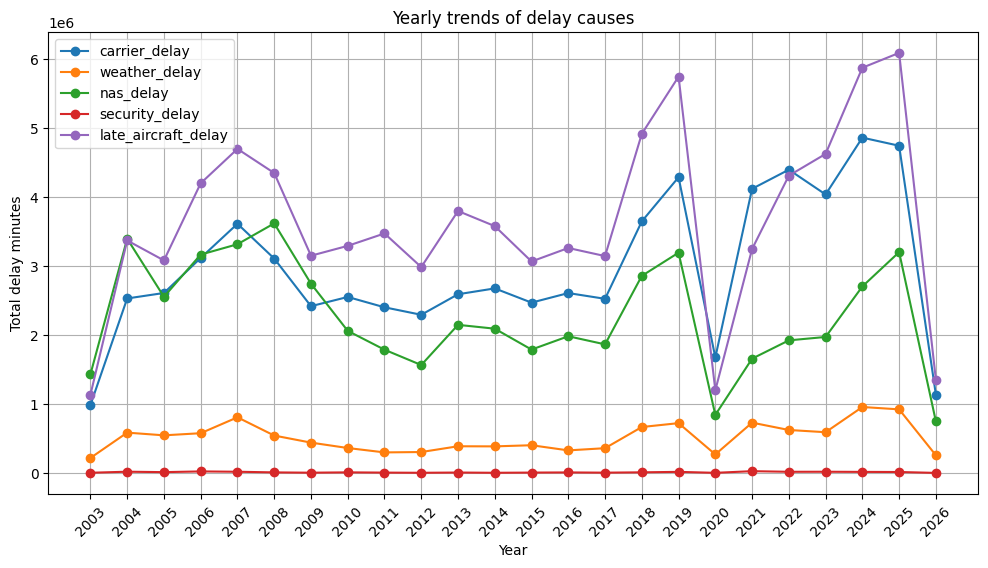

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# Create delay cause columns
delay_causes = [
    'carrier_delay',
    'weather_delay',
    'nas_delay',
    'security_delay',
    'late_aircraft_delay'
]

# Aggregate monthly data into yearly totals
yearly_df = df.groupby('year')[delay_causes].sum()

# Check the result
print(yearly_df.head())

# Plot yearly trends
plt.figure(figsize=(12,6))

for cause in delay_causes:
    plt.plot(
        yearly_df.index,
        yearly_df[cause],
        marker='o',
        label=cause
    )

plt.xticks(yearly_df.index, rotation=45)

plt.xlabel("Year")
plt.ylabel("Total delay minutes")
plt.title("Yearly trends of delay causes")
plt.legend()
plt.grid(True)
plt.show()

In [43]:
pip install plotly

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## Interactive exploration

In [44]:
import pandas as pd
import plotly.express as px

# Create yearly totals
yearly_df = df.groupby("year")[delay_causes].sum().reset_index()

# Convert to long format for Plotly
yearly_long = yearly_df.melt(
    id_vars="year",
    var_name="Delay Cause",
    value_name="Delay Minutes"
)

# Interactive line chart
fig = px.line(
    yearly_long,
    x="year",
    y="Delay Minutes",
    color="Delay Cause",
    markers=True,
    title="Yearly Trends of Flight Delay Causes",
    hover_data={
        "year": True,
        "Delay Minutes": ":,"
    }
)

# Improve layout
fig.update_layout(
    width=1000,
    height=600,
    title_x=0.5,
    xaxis_title="Year",
    yaxis_title="Total Delay Minutes",
    legend_title="Delay Cause"
)

# Allow clicking legend items to hide/show causes
fig.update_traces(line=dict(width=3))

fig.show()

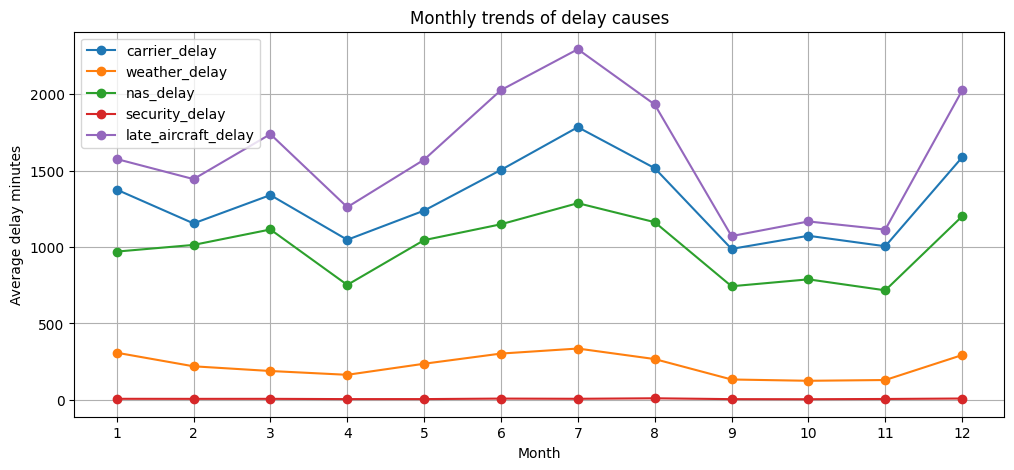

In [45]:
monthly_pattern = df.groupby('month')[delay_causes].mean()

monthly_pattern.plot(
    figsize=(12,5),
    marker='o'
)

plt.title("Monthly trends of delay causes")
plt.xlabel("Month")
plt.ylabel("Average delay minutes")
plt.xticks(range(1,13))
plt.grid(True)
plt.show()

## Seasonal patterns of delay causes

In [46]:
#pip install seaborn

In [47]:
import seaborn as sns

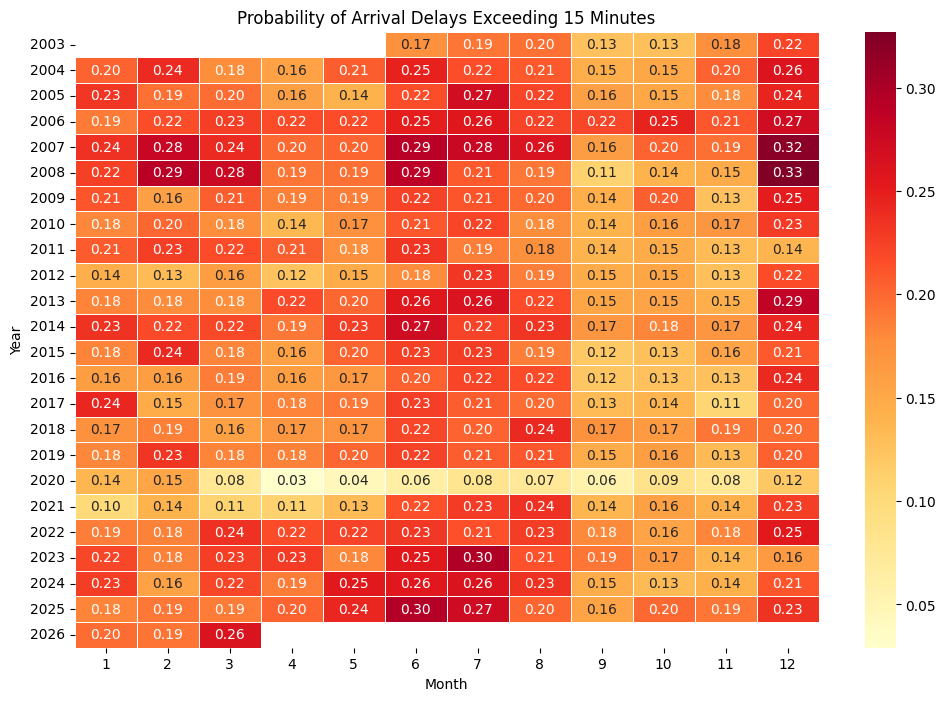

In [48]:
# aggregate monthly delay data
monthly_delay = (
    df.groupby(["year", "month"])
    .agg(
        total_arrivals=("arr_flights", "sum"),
        total_arrdel15=("arr_del15", "sum")
    )
    .reset_index()
)

# calculate probability of arrival delay P(arrival delay15∣arrival flight)
monthly_delay["arr_delay_ratio"] = (
    monthly_delay["total_arrdel15"] /
    monthly_delay["total_arrivals"]
)

# reshape for heatmap
heatmap_data = monthly_delay.pivot(
    index="year",
    columns="month",
    values="arr_delay_ratio"
)

plt.figure(figsize=(12,8))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Probability of Arrival Delays Exceeding 15 Minutes")
plt.xlabel("Month")
plt.ylabel("Year")

plt.show()

# STL Decomposition

** Observed=Trend+Seasonal+Residual ** additiven Modell

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

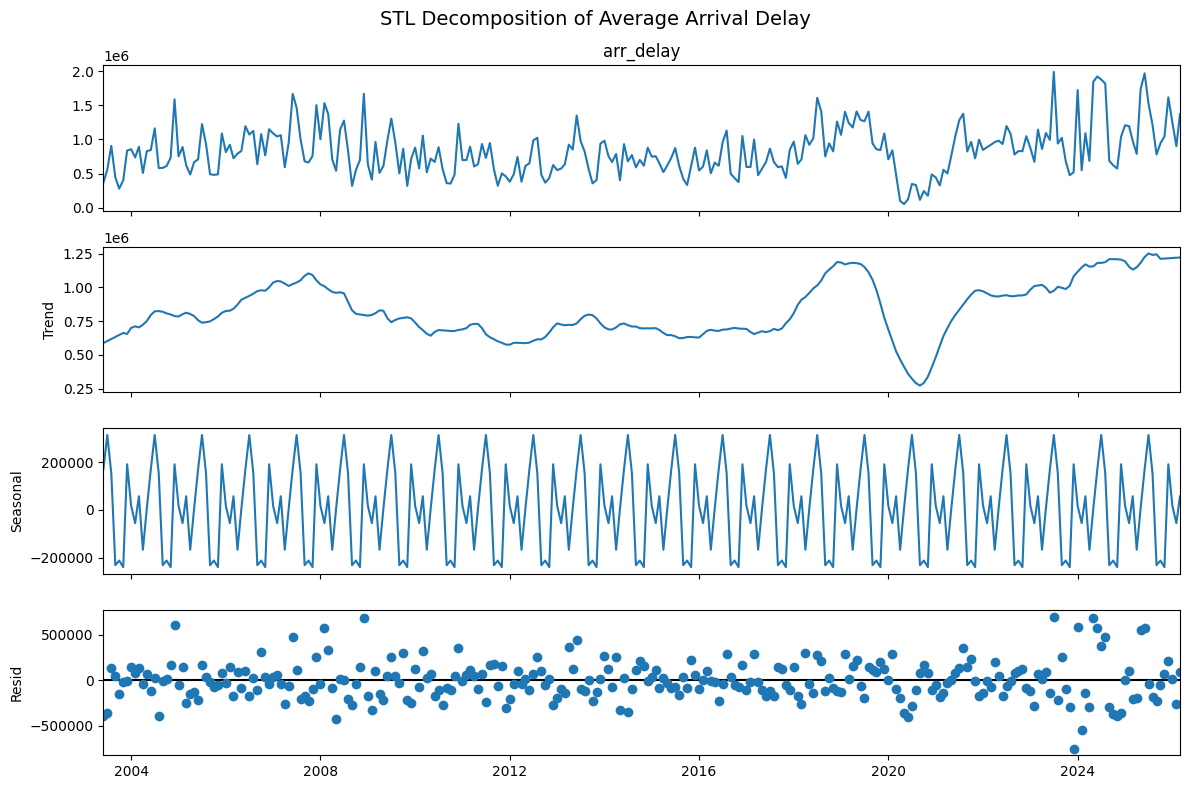

In [50]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Create monthly datetime index
df["date"] = pd.to_datetime(
    df[["year", "month"]].assign(DAY=1)
)

df = df.set_index("date")

# groups the arrival delay data by month with month start and calculate the total delay minutes
ts = df["arr_delay"].resample("MS").sum()

# STL decomposition with yearly seasonality
stl_arr = seasonal_decompose(
    ts,
    model="additive",
    period=12,
    extrapolate_trend="freq"
)

# Plot
fig = stl_arr.plot()
fig.set_size_inches(12, 8)

plt.suptitle(
    "STL Decomposition of Average Arrival Delay",
    fontsize=14
)

plt.tight_layout()
plt.show()